In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print("数据加载成功！")

Matplotlib is building the font cache; this may take a moment.


数据加载成功！


In [4]:
# Check train and test dataset shapes
print("Train dataset shape (rows, cols):", train.shape)
print("Test dataset shape (rows, cols):", test.shape)

# Display dataset column summary and data types
train.info()

Train dataset shape (rows, cols): (1460, 81)
Test dataset shape (rows, cols): (1459, 80)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     146

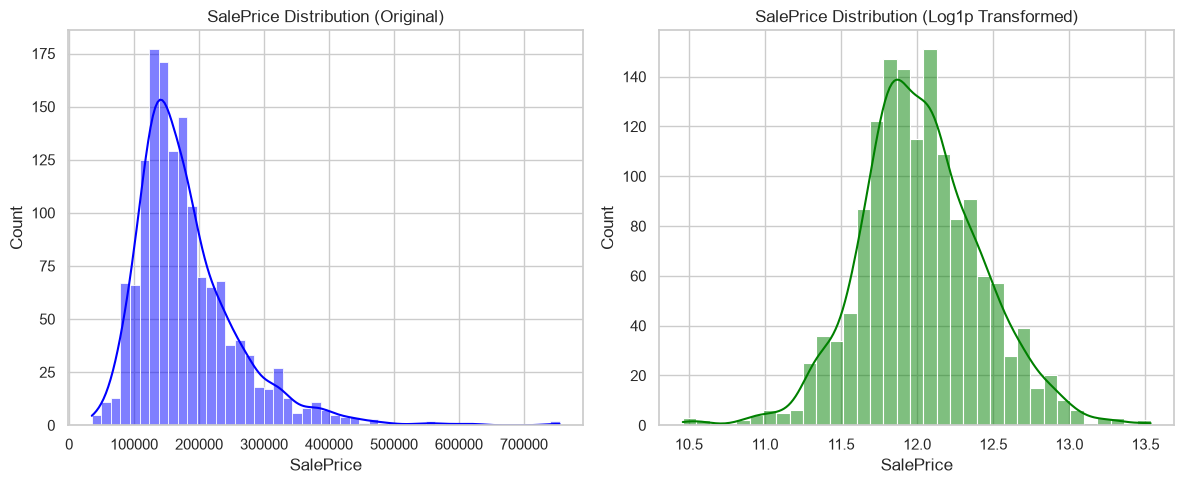

In [5]:
plt.figure(figsize=(12, 5))

# Plot 1: Original SalePrice distribution
plt.subplot(1, 2, 1)
sns.histplot(train['SalePrice'], kde=True, color='blue')
plt.title('SalePrice Distribution (Original)')

# Plot 2: Log1p transformed SalePrice distribution
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train['SalePrice']), kde=True, color='green')
plt.title('SalePrice Distribution (Log1p Transformed)')

plt.tight_layout()
plt.show()

In [6]:
# Calculate missing value counts for each feature
missing = train.isnull().sum()

# Filter features with missing values and sort descending
missing = missing[missing > 0].sort_values(ascending=False)

# Display top 10 features with missing values
print("Top 10 features with missing values:\n", missing.head(10))

Top 10 features with missing values:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64


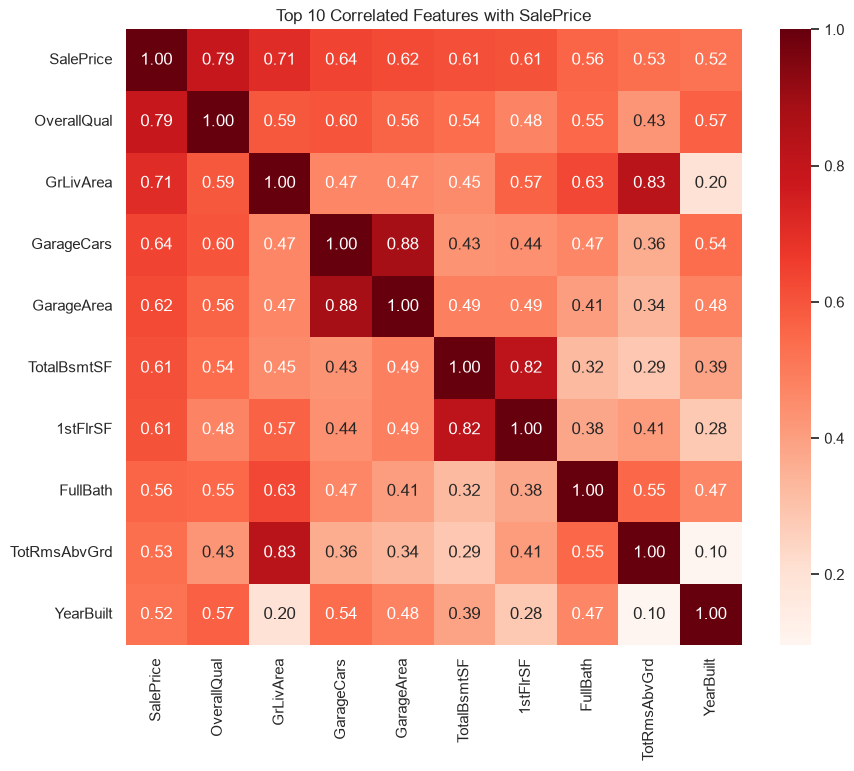

In [7]:
# Select numeric features only
numeric_train = train.select_dtypes(include=[np.number])

# Calculate correlation matrix
corrmat = numeric_train.corr()

# Find top 10 features with highest correlation to SalePrice
k = 10
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(train[cols].values.T)

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, square=True, fmt='.2f', 
            yticklabels=cols.values, xticklabels=cols.values, cmap='Reds')
plt.title('Top 10 Correlated Features with SalePrice')
plt.show()

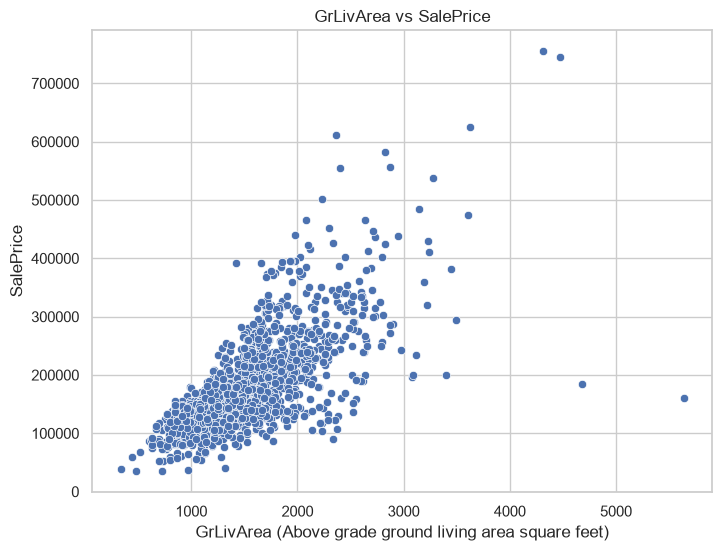

Outlier sample IDs:
 [ 524 1299]


In [9]:
# Scatter plot of GrLivArea vs SalePrice
plt.figure(figsize=(8, 6))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])
plt.title('GrLivArea vs SalePrice')
plt.xlabel('GrLivArea (Above grade ground living area square feet)')
plt.ylabel('SalePrice')

import os
os.makedirs("../assets", exist_ok=True)
plt.savefig("../assets/eda_saleprice_distribution.png", dpi=150, bbox_inches="tight")

plt.show()

# Detect outliers with GrLivArea > 4000 and SalePrice < 300000
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
print("Outlier sample IDs:\n", outliers['Id'].values)